In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

In [2]:
# ============================================
# Step 1 — Load features
# ============================================

df = pd.read_csv("../data/processed/features.csv")

feature_cols = [
    "home_team_enc", "away_team_enc",
    "home_form", "away_form", "form_diff",
    "home_h2h_rate", "is_neutral","home_rank",
    "away_rank","rank_diff"

]

X = df[feature_cols]
y = df["result"]

print(f"Loaded {len(df)} rows")
print(f"Class distribution:\n{y.value_counts()}")

Loaded 32314 rows
Class distribution:
result
Home Win    15666
Away Win     9048
Draw         7600
Name: count, dtype: int64


In [3]:
# ============================================
# Step 2 — Train/test split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {len(X_train)} rows | Test: {len(X_test)} rows")


Train: 25851 rows | Test: 6463 rows


In [4]:
# ============================================
# Step 3 — Define models to compare
# ============================================
# All four of these work directly with text labels
# ("Home Win", "Away Win", "Draw") — no extra encoding needed.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, max_depth=3, random_state=42
    ),
}





In [5]:
# ============================================
# Step 4 — Train and evaluate every model
# ============================================

results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, pred)

    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Overfit Gap": train_acc - test_acc
    })

    trained_models[name] = model
    predictions[name] = pred

    print(f"{name:22s} | test acc: {test_acc:.2%}")

Logistic Regression    | test acc: 54.88%
KNN                    | test acc: 49.53%
Random Forest          | test acc: 55.83%
Gradient Boosting      | test acc: 55.64%



=== Model comparison ===
              Model  Train Accuracy  Test Accuracy  Overfit Gap
      Random Forest           0.625          0.558        0.067
  Gradient Boosting           0.588          0.556        0.032
Logistic Regression           0.563          0.549        0.014
                KNN           0.581          0.495        0.086


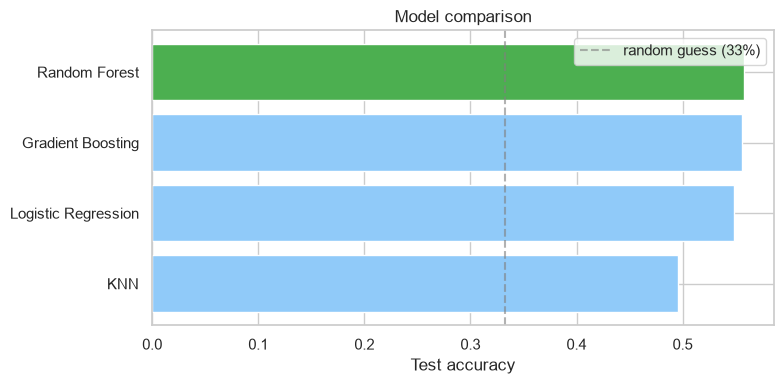

In [6]:
# ============================================
# Step 5 — Compare results in a table and chart
# ============================================

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
results_df = results_df.reset_index(drop=True)

print("\n=== Model comparison ===")
print(results_df.round(3).to_string(index=False))

plt.figure(figsize=(8, 4))
colors = ["#4CAF50" if i == 0 else "#90CAF9" for i in range(len(results_df))]
plt.barh(results_df["Model"], results_df["Test Accuracy"], color=colors)
plt.xlabel("Test accuracy")
plt.title("Model comparison")
plt.axvline(0.333, color="gray", linestyle="--", alpha=0.6, label="random guess (33%)")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Best model: Random Forest
Test accuracy: 55.83%

=== Classification report ===
              precision    recall  f1-score   support

    Away Win       0.49      0.52      0.51      1810
        Draw       0.33      0.01      0.03      1520
    Home Win       0.59      0.84      0.69      3133

    accuracy                           0.56      6463
   macro avg       0.47      0.46      0.41      6463
weighted avg       0.50      0.56      0.48      6463



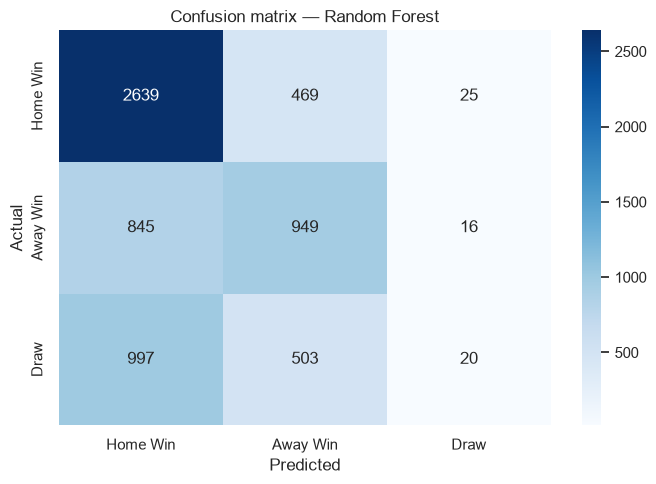

In [7]:
# ============================================
# Step 6 — Pick the best model and inspect it
# ============================================

best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
best_pred = predictions[best_name]

print(f"\nBest model: {best_name}")
print(f"Test accuracy: {results_df.iloc[0]['Test Accuracy']:.2%}")

print("\n=== Classification report ===")
print(classification_report(y_test, best_pred))

classes = ["Home Win", "Away Win", "Draw"]
cm = confusion_matrix(y_test, best_pred, labels=classes)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

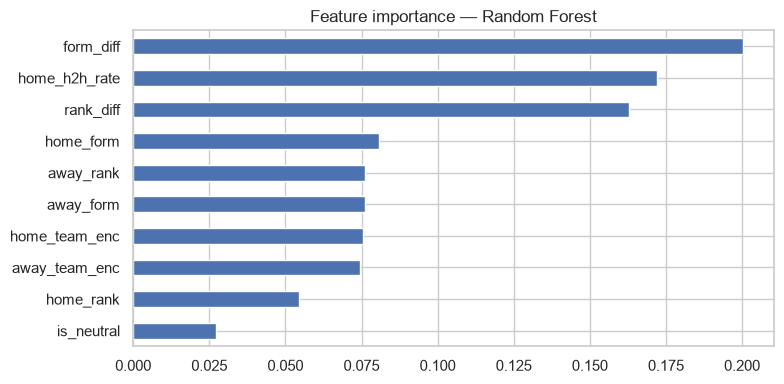

In [8]:
# ============================================
# Step 7 — Feature importance (Random Forest / Gradient Boosting only)
# ============================================

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(
        best_model.feature_importances_, index=feature_cols
    ).sort_values()

    plt.figure(figsize=(8, 4))
    importances.plot(kind="barh")
    plt.title(f"Feature importance — {best_name}")
    plt.tight_layout()
    plt.show()


In [9]:
# ============================================
# Step 8 — Save the best model
# ============================================

os.makedirs("../models", exist_ok=True)
pickle.dump(best_model, open("../models/match_model.pkl", "wb"))
results_df.to_csv("../models/model_comparison.csv", index=False)

print(f"\nSaved {best_name} to models/match_model.pkl")


Saved Random Forest to models/match_model.pkl


In [10]:
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# F1 score
f1 = f1_score(y_test, best_pred, average="weighted")

# ROC AUC — needs probability scores and binarized labels
classes_list = ["Home Win", "Away Win", "Draw"]
y_test_bin = label_binarize(y_test, classes=classes_list)
y_prob = best_model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="weighted")

# Save all metrics to a file
metrics = {
    "model_name": best_name,
    "accuracy": round(results_df.iloc[0]["Test Accuracy"], 4),
    "f1_score": round(f1, 4),
    "roc_auc": round(roc_auc, 4)
}

import json
with open("../models/metrics.json", "w") as f:
    json.dump(metrics, f)

print(f"Model: {best_name}")
print(f"Accuracy: {metrics['accuracy']:.2%}")
print(f"F1 Score: {metrics['f1_score']:.2%}")
print(f"ROC AUC:  {metrics['roc_auc']:.2%}")
print("Saved to models/metrics.json")

Model: Random Forest
Accuracy: 55.83%
F1 Score: 48.45%
ROC AUC:  39.68%
Saved to models/metrics.json
